In [29]:
import numpy as np
import gempy as gp
import pandas as pd
import gempy as gp
import gempy_viewer as gpv
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import rasterio
import os
import pyvista as pv

import geomodel_toolbox
import importlib

importlib.reload(geomodel_toolbox)

<module 'geomodel_toolbox' from 'c:\\Users\\ethan\\MSc-Thesis\\GeoModel\\geomodel_toolbox.py'>

In [30]:
#  ====
# Inputs
#  ====

x_lims = (369702.8, 374398.9)
y_lims = (407778.9, 411690.2)
z_lims = (300, -2000)

resolution = [100, 100, 60]   # nx, ny, nz
 
strat_azimuth = 135 #deg
strat_dip = 10 #deg

#fracture map

aperture = [50, 50] #[m] [MEAN, STD]
radius = [1000, 100] #[m] [MEAN, STD]
azimuth = [45, 10] #[deg] [MEAN, STD]

density = 4e-9 #[fractures/m3]

In [31]:
# 1. Create DEM file: 
if os.path.isfile("subset_dem.tif"): 
    pass
else: 
    #Original file downloaded from https://dem.gis.is/mapview/?application=DEM (too big for github)
    geomodel_toolbox.create_subset_dem(x_lims, y_lims, target_resolution=10) #NB: need to download original DEM 

# Plot and check DEM if required
#geomodel_toolbox.plot_dem('subset_dem.tif')
geomodel_toolbox.get_info_dem('subset_dem.tif')

projection: EPSG:3057
BoundingBox(left=369702.8, bottom=407780.2, right=374392.8, top=411690.2)
res: (10.0, 10.0)
nx, ny: 469 391


In [32]:
# 2. Create/update input files for gempy: 
geomodel_toolbox.create_dfs_4_gempy(azimuth=strat_azimuth, dip=strat_dip)

Active grids: GridTypes.NONE|TOPOGRAPHY|DENSE


c:\Users\ethan\anaconda3\envs\gempy310\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=Strat_Series1,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=unknown,
	color=#5DA629,
	is_active=True
),
Element(
	name=B1,
	color=#015482,
	is_active=True
),
Element(
	name=M1,
	color=#728f02,
	is_active=True
),
Element(
	name=B2,
	color=#9f0052,
	is_active=True
),
Element(
	name=M2,
	color=#443988,
	is_active=True
),
Element(
	name=B3,
	color=#ffbe00,
	is_active=True
),
Element(
	name=M3,
	color=#ff3f20,
	is_active=True
)
]
)
],
	fault_relations=
[[False]],

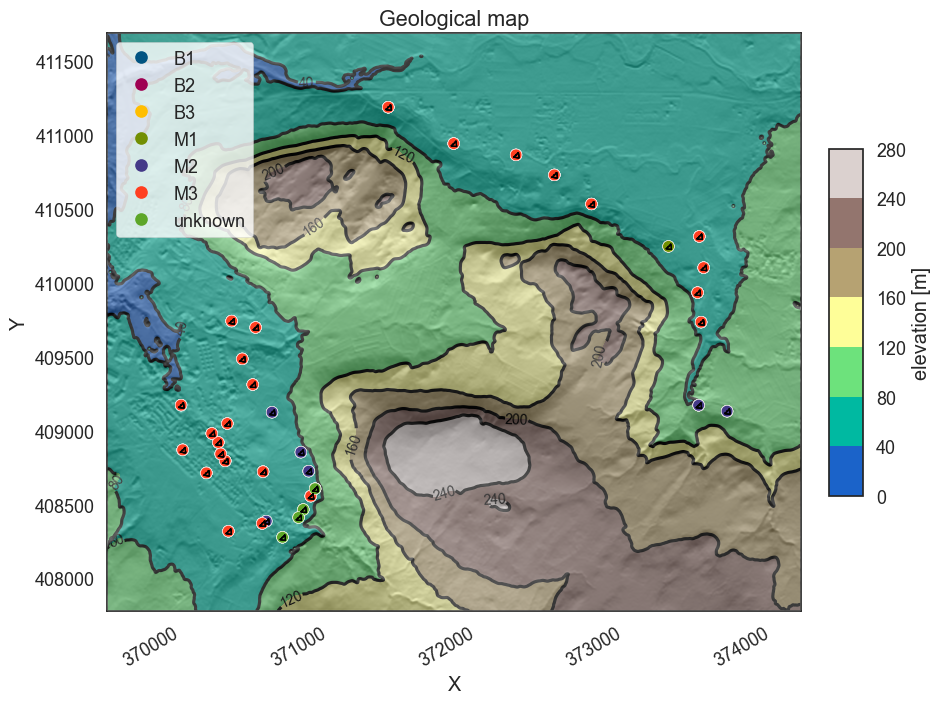

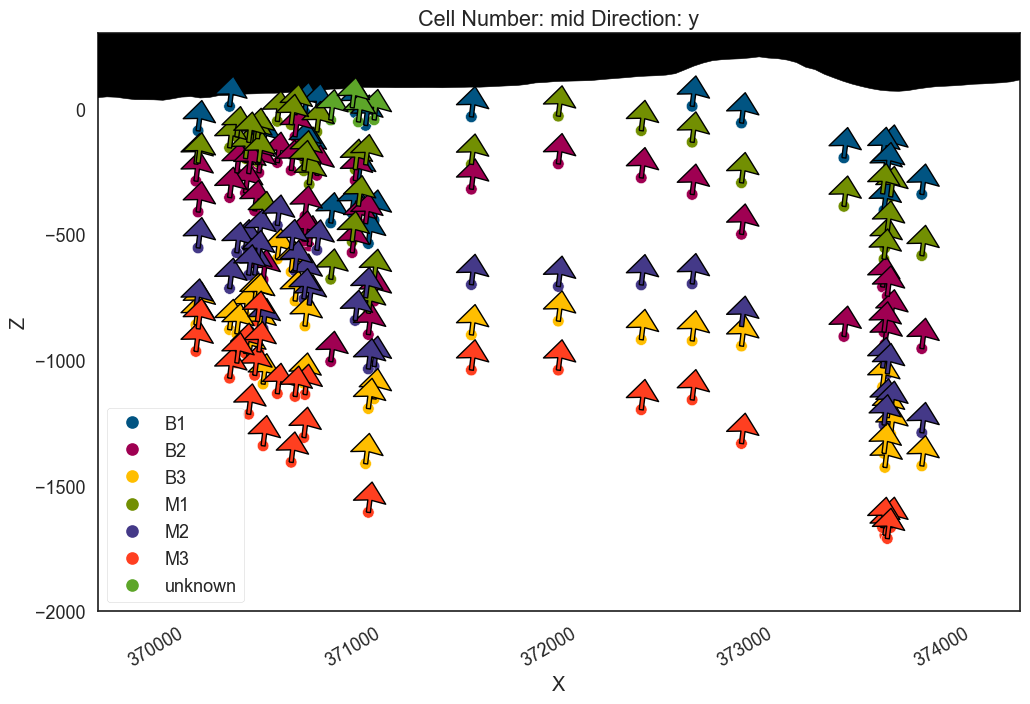

In [33]:
# 3. Use gempy to make model
extent = x_lims+y_lims+z_lims[::-1]

# Create instance of geomodel
geo_model = gp.create_geomodel(
    project_name = 'tutorial_model',
    extent=extent,
    resolution=resolution,
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations='gempy_inputs/df_orientations_4gempy.csv',
        path_to_surface_points='gempy_inputs/df_surfaces_4gempy.csv'
    )
)

# Add topography
gp.set_topography_from_file(
    grid=geo_model.grid,
    filepath='subset_dem.tif')

#Plot map
gpv.plot_2d(geo_model, show_topography=True, section_names=['topography'])

# Display a basic cross section of input data
gpv.plot_2d(geo_model, show_topography=True)

# Define structural groups and age/stratigraphic relationship
gp.map_stack_to_surfaces(
    gempy_model=geo_model,
    mapping_object={
        "Strat_Series1": ('unknown', 'B1', 'M1', 'B2', 'M2', 'B3', 'M3')
        }
)

c:\Users\ethan\MSc-Thesis\GeoModel\geomodel_toolbox.py:241: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  res = geomodel.grid.regular_grid.resolution #10, 10, 60


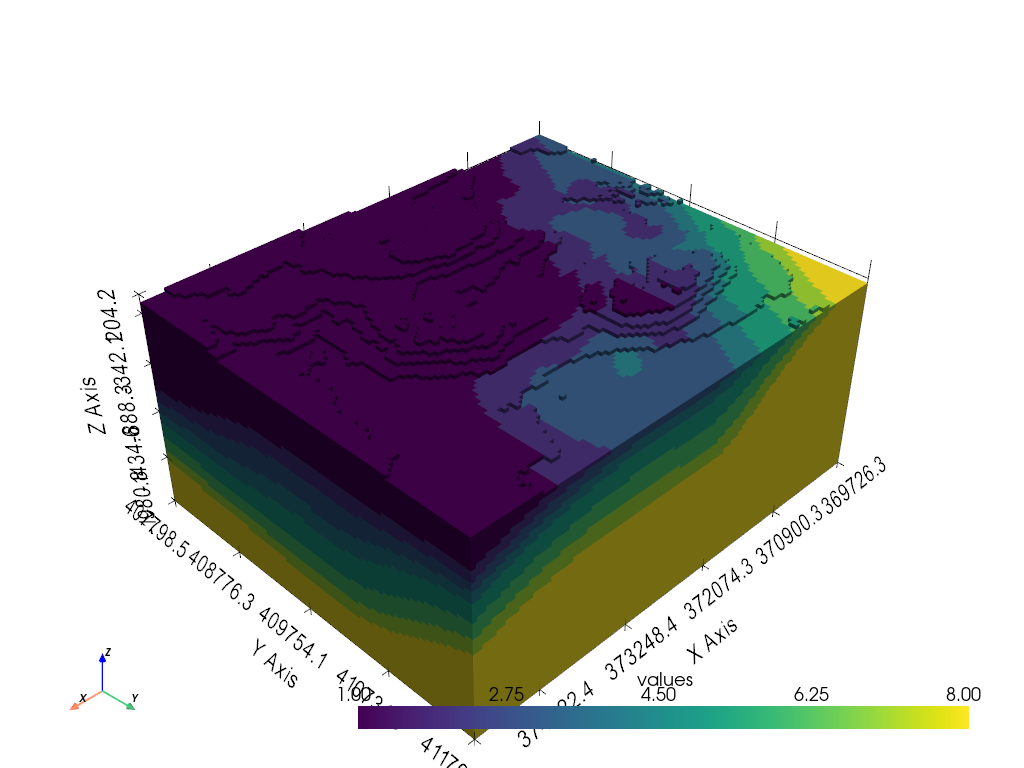

In [34]:
# 4. Run the model and save it (or visualized the saved one for faster results)
force_run = False
if os.path.isfile("gempy_outputs/lith_topo.npy") and not force_run: 
    # Import saved files
    lith_topo = np.load('gempy_outputs/lith_topo.npy')
    x_array = np.load('gempy_outputs/x_array.npy')
    y_array = np.load('gempy_outputs/y_array.npy')
    z_array = np.load('gempy_outputs/z_array.npy')

    # Check sizes
    #print(lith_topo.shape)
    #print(x_array.shape, y_array.shape, z_array.shape)
    
    # Plot 3D model
    geomodel_toolbox.plot_3d_model(geomodel=lith_topo, x=x_array, y=y_array, z=z_array, downsampling=1)
    
else: 
    # Compute a solution for the model (takes 17 mins. )
    gp.compute_model(geo_model)

    # Display the result in 2d section
    gpv.plot_2d(geo_model, show_topography=True)

    # Save the results
    geomodel_toolbox.save_gempy_results(geomodel=geo_model)